## scenario 2 = Imbalanced + EDA + tidak drop enhanced_casual_severity (ingin lihat pengaruh fitur enhanced_casualty_severity)

In [1]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46649 entries, 0 to 46648
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              44293 non-null  object 
 1   collision_index                     46649 non-null  object 
 2   collision_year                      44261 non-null  float64
 3   collision_reference                 44343 non-null  object 
 4   vehicle_reference                   46649 non-null  float64
 5   casualty_reference                  46649 non-null  float64
 6   casualty_class                      46649 non-null  int64  
 7   sex_of_casualty                     44319 non-null  float64
 8   age_of_casualty                     46649 non-null  int64  
 9   age_band_of_casualty                46649 non-null  int64  
 10  pedestrian_location                 46649 non-null  float64
 11  pedestrian_movement                 46649

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,44261.0,46649.000000,46649.000000,46649.000000,44319.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,44314.000000,46649.000000,44292.000000,46649.000000,46649.000000,46649.000000
mean,2024.0,1.455616,1.353898,1.485520,1.366637,37.102982,6.326502,0.795227,0.657442,0.196574,0.058072,0.031548,9.314112,0.993227,4.132307,1.582220,2.882741
std,0.0,1.444068,1.267332,0.732898,0.577406,19.826586,2.493991,2.196648,2.047634,0.647400,0.465305,0.286917,15.842578,0.979042,3.286280,2.273239,0.362108
min,2024.0,0.462251,0.595506,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,202.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [2]:
#Cek missing values

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()


status                                2356
collision_year                        2388
collision_reference                   2306
sex_of_casualty                       2330
pedestrian_road_maintenance_worker    2335
casualty_home_area_type               2357
dtype: int64


,0
status,2356
collision_index,0
collision_year,2388
collision_reference,2306
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,2330
age_of_casualty,0
age_band_of_casualty,0


In [3]:
df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty",], inplace=True)

#imputasi dengan modus
sex_mode = df["sex_of_casualty"].mode()[0]
df["sex_of_casualty"].fillna(sex_mode, inplace=True)

#imputasi dengan modus
worker_mode = df["pedestrian_road_maintenance_worker"].mode()[0]
df["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)

#imputasi dengan modus
area_type_mode = df["casualty_home_area_type"].mode()[0]
df["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()

Series([], dtype: int64)


/tmp/ipython-input-3-341705777.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sex_of_casualty"].fillna(sex_mode, inplace=True)
/tmp/ipython-input-3-341705777.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
collision_index,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
age_band_of_casualty,0
pedestrian_location,0
pedestrian_movement,0
car_passenger,0


In [5]:
!pip install xgboost

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, VotingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
import pandas as pd

# Salin data
train = df.copy()
X = train.drop(columns=['casualty_severity'])
y = train['casualty_severity'] - 1  # Encoding label

# Label encoding
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Split data
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Daftar semua model
classifiers = [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=random_state)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("ExtraTrees", ExtraTreesClassifier(random_state=random_state)),
    ("Bagging", BaggingClassifier(random_state=random_state)),
    ("AdaBoost", AdaBoostClassifier(random_state=random_state)),
    ("GradientBoost", GradientBoostingClassifier(random_state=random_state)),
    ("HistGradientBoost", HistGradientBoostingClassifier(random_state=random_state)),
    ("XGBoost", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis())
]

# Voting classifier
voting = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ('gb', GradientBoostingClassifier(random_state=random_state)),
    ('rf', RandomForestClassifier(random_state=random_state))
], voting='soft')

classifiers.append(("Voting", voting))

# Evaluasi cross-validation
cv_results = []
for name, model in classifiers:
    try:
        scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=kfold, n_jobs=-1)
        cv_results.append((name, scores.mean(), scores.std()))
    except Exception as e:
        print(f"Model {name} gagal dievaluasi: {e}")

# Hasil evaluasi
cv_res = pd.DataFrame(cv_results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
cv_res = cv_res.sort_values(by='CrossValMeans', ascending=False)
print("Fitur yang digunakan:\n", X.columns.tolist())
print(cv_res)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 3.3 MB/s eta 0:00:00
Fitur yang digunakan:
 ['collision_index', 'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'enhanced_casualty_severity']
             Algorithm  CrossValMeans  CrossValStd
9    HistGradientBoost       0.968006     0.000918
13              Voting       0.967979     0.000743
8        GradientBoost       0.967389     0.000701
10             XGBoost       0.966719     0.000898
4        Random Forest       0.966478     0.000840
5           ExtraTrees       0.963906     0.001073
6              Bagging       0.960583     0.000936
7             AdaBoost       0.956376     

In [6]:
!pip install optuna

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === HistGradientBoost ===
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_iter": trial.suggest_int("max_iter", 100, 300),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 50),
        "l2_regularization": trial.suggest_float("l2_regularization", 0, 2),
    }
    model = HistGradientBoostingClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_hgb = optuna.create_study(direction="maximize")
study_hgb.optimize(objective_hgb, n_trials=30)

# === GradientBoost ===
def objective_gb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_gb = optuna.create_study(direction="maximize")
study_gb.optimize(objective_gb, n_trials=30)

# === VotingClassifier (XGB + GB + RF) ===
def objective_vote(trial):
    voting_type = trial.suggest_categorical("voting", ["soft", "hard"])
    model = VotingClassifier(estimators=[
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ], voting=voting_type)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_vote = optuna.create_study(direction="maximize")
study_vote.optimize(objective_vote, n_trials=30)

print("=== Best HistGradientBoost Hyperparameters ===")
print(study_hgb.best_params)
print("Best HistGradientBoost Accuracy:", study_hgb.best_value)

print("\n=== Best GradientBoost Hyperparameters ===")
print(study_gb.best_params)
print("Best GradientBoost Accuracy:", study_gb.best_value)

print("\n=== Best Voting Hyperparameters ===")
print(study_vote.best_params)
print("Best Voting Accuracy:", study_vote.best_value)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.5/585.5 kB 34.6 MB/s eta 0:00:00


[I 2025-06-23 09:35:37,232] A new study created in memory with name: no-name-31537ee1-08c9-4a22-ae42-203f57be60ef
[I 2025-06-23 09:35:40,928] Trial 0 finished with value: 0.9677912284382877 and parameters: {'learning_rate': 0.10080599150234057, 'max_iter': 147, 'max_leaf_nodes': 59, 'min_samples_leaf': 44, 'l2_regularization': 0.8535343476340043}. Best is trial 0 with value: 0.9677912284382877.
[I 2025-06-23 09:35:44,532] Trial 1 finished with value: 0.9681395779019297 and parameters: {'learning_rate': 0.07230350072552932, 'max_iter': 228, 'max_leaf_nodes': 34, 'min_samples_leaf': 33, 'l2_regularization': 0.31628653299827536}. Best is trial 1 with value: 0.9681395779019297.
[I 2025-06-23 09:35:47,121] Trial 2 finished with value: 0.9680591920498397 and parameters: {'learning_rate': 0.11241454760827743, 'max_iter': 292, 'max_leaf_nodes': 30, 'min_samples_leaf': 39, 'l2_regularization': 1.3684996134119483}. Best is trial 1 with value: 0.9681395779019297.
[I 2025-06-23 09:35:49,439] Trial

=== Best HistGradientBoost Hyperparameters ===
{'learning_rate': 0.011991360879222028, 'max_iter': 176, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'l2_regularization': 0.05647683330090844}
Best HistGradientBoost Accuracy: 0.968380739048617

=== Best GradientBoost Hyperparameters ===
{'n_estimators': 299, 'learning_rate': 0.025871988486202365, 'max_depth': 4, 'subsample': 0.7797331918681135, 'max_features': None}
Best GradientBoost Accuracy: 0.9682199493923506

=== Best Voting Hyperparameters ===
{'voting': 'soft'}
Best Voting Accuracy: 0.9679787918360805


In [7]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import (
    HistGradientBoostingClassifier, GradientBoostingClassifier, VotingClassifier, RandomForestClassifier
)
from xgboost import XGBClassifier

# === Model 1: HistGradientBoost ===
hgb_best = HistGradientBoostingClassifier(
    learning_rate=0.011991360879222028,
    max_iter=176,
    max_leaf_nodes=17,
    min_samples_leaf=12,
    l2_regularization=0.05647683330090844,
    random_state=42
)
hgb_best.fit(X_train, y_train)
y_pred_hgb = hgb_best.predict(X_test)

print("=== HistGradientBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_hgb))
print(classification_report(y_test, y_pred_hgb))

# === Model 2: GradientBoost ===
gb_best = GradientBoostingClassifier(
    n_estimators=299,
    learning_rate=0.025871988486202365,
    max_depth=4,
    subsample=0.7797331918681135,
    max_features=None,
    random_state=42
)
gb_best.fit(X_train, y_train)
y_pred_gb = gb_best.predict(X_test)

print("\n=== GradientBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# === Model 3: VotingClassifier ===
voting_best = VotingClassifier(
    estimators=[
        ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ],
    voting='soft'
)
voting_best.fit(X_train, y_train)
y_pred_vote = voting_best.predict(X_test)

print("\n=== VotingClassifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))


=== HistGradientBoost ===
Accuracy: 0.9673097534833869
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       129
           1       1.00      0.68      0.81       836
           2       0.96      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.98      0.81      0.88      9330
weighted avg       0.97      0.97      0.96      9330


=== GradientBoost ===
Accuracy: 0.9673097534833869
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       129
           1       1.00      0.68      0.81       836
           2       0.97      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.98      0.81      0.88      9330
weighted avg       0.97      0.97      0.96      9330



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:58:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== VotingClassifier ===
Accuracy: 0.967416934619507
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       129
           1       1.00      0.68      0.81       836
           2       0.96      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.99      0.81      0.88      9330
weighted avg       0.97      0.97      0.96      9330



In [9]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. One-hot encode target (karena deep learning pakai softmax)
y_dl = to_categorical(y)

# 2. Split (gunakan data sebelum SMOTE agar setara dengan model klasik)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X, y_dl, test_size=0.2, stratify=y, random_state=42
)
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))  # karena klasifikasi 3 kelas
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_dl, y_train_dl,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    verbose=1)
# Evaluasi akurasi
test_loss, test_acc = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\n✅ Deep Learning Test Accuracy: {test_acc:.4f}")

# Prediksi dan klasifikasi report
y_pred_dl = model.predict(X_test_dl)
y_pred_labels = tf.argmax(y_pred_dl, axis=1)
y_true_labels = tf.argmax(y_test_dl, axis=1)

print("\n=== Deep Learning Classification Report ===")
print(classification_report(y_true_labels, y_pred_labels))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


933/933 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8103 - loss: 137.2964 - val_accuracy: 0.9003 - val_loss: 0.5036
Epoch 2/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8902 - loss: 1.0505 - val_accuracy: 0.9003 - val_loss: 0.3866
Epoch 3/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8935 - loss: 0.5338 - val_accuracy: 0.9003 - val_loss: 0.3701
Epoch 4/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8942 - loss: 0.4124 - val_accuracy: 0.9003 - val_loss: 0.3664
Epoch 5/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8973 - loss: 0.4347 - val_accuracy: 0.9003 - val_loss: 0.3654
Epoch 6/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8948 - loss: 0.3798 - val_accuracy: 0.9003 - val_loss: 0.3651
Epoch 7/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8966 - loss: 0.3766 - val_accuracy: 0.9003 - val_loss: 0.3650
Epoch 8/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8953 - loss: 0.3842 - val_accuracy: 0.9003 - va

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


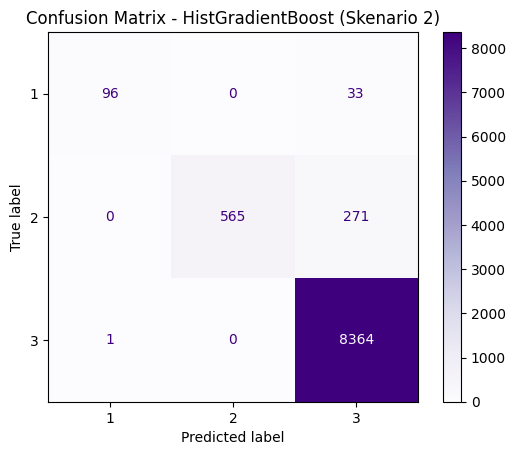

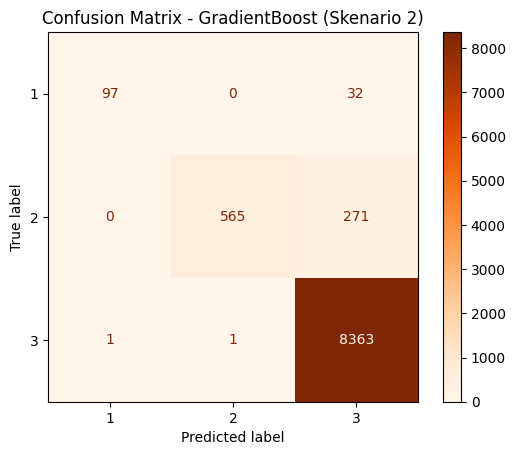

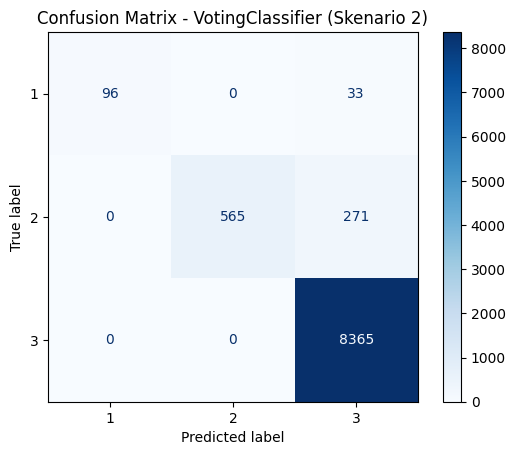

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === Confusion Matrix: HistGradientBoost ===
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
disp_hgb = ConfusionMatrixDisplay(confusion_matrix=cm_hgb, display_labels=[1, 2, 3])
disp_hgb.plot(cmap='Purples')
plt.title("Confusion Matrix - HistGradientBoost (Skenario 2)")
plt.show()

# === Confusion Matrix: GradientBoost ===
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=[1, 2, 3])
disp_gb.plot(cmap='Oranges')
plt.title("Confusion Matrix - GradientBoost (Skenario 2)")
plt.show()

# === Confusion Matrix: VotingClassifier ===
cm_vote = confusion_matrix(y_test, y_pred_vote)
disp_vote = ConfusionMatrixDisplay(confusion_matrix=cm_vote, display_labels=[1, 2, 3])
disp_vote.plot(cmap='Blues')
plt.title("Confusion Matrix - VotingClassifier (Skenario 2)")
plt.show()
